# Time-to-Event Regression — Last 7 Days  |  embed_dim=128

Predicts **days until hospital admission** (time to event) from home ventilator data.

- **Model**: Time-aware Transformer with Time2Vec (embed_dim=128, nhead=4, hidden=512)
- **Loss**: MSE (optimised) + MAE (reported)
- **Target**: log1p MinMax-scaled time to event (0–6 days)
- **Data**: label-1 patients only (hospitalised), last 7 days of monitoring
- **Save**: `Best_Model/regression_last7days/128dim/best_model.pth`


---
## Step 1 — Install & Import

In [ ]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas pyarrow tqdm


In [ ]:
import os, gc, math, contextlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import amp
from torch.cuda.amp import GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: Tesla T4


---
## Step 2 — Mount Drive & Load Label-1 Data

Loads pre-filtered label-1-only parquet directly — no re-filtering needed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE         = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data"
LABEL1_DIR   = os.path.join(BASE, 'last7days_rawdata_label1only_parquet')
SAVE_DIR     = os.path.join(BASE, 'Best_Model', 'regression_last7days')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Label-1 data : {LABEL1_DIR}')
print(f'Save dir     : {SAVE_DIR}')

print('\nLoading label-1 only parquet...')
df_train = pd.read_parquet(os.path.join(LABEL1_DIR, 'train.parquet'))
df_val   = pd.read_parquet(os.path.join(LABEL1_DIR, 'val.parquet'))
df_test  = pd.read_parquet(os.path.join(LABEL1_DIR, 'test.parquet'))

print(f'Train: {len(df_train):,} rows  {df_train["patient_id"].nunique()} patients')
print(f'Val  : {len(df_val):,} rows  {df_val["patient_id"].nunique()} patients')
print(f'Test : {len(df_test):,} rows  {df_test["patient_id"].nunique()} patients')
df_train.head(3)


Mounted at /content/drive
Label-1 data : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/last7days_rawdata_label1only_parquet
Save dir     : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days

Loading label-1 only parquet...
Train: 32,455,977 rows  19 patients
Val  : 8,778,214 rows  5 patients
Test : 5,877,474 rows  5 patients


,timestamp,test_type,test_value,patient_id,label,start_date,end_date,machine_year_full,delta_time_seconds,time_from_start_seconds,patient_span_days,hour_of_day,hour_of_day_scaled,countdown_days_target,countdown_days_log_target,countdown_days_target_scaled,countdown_days_log_target_scaled,test_value_scaled,time_from_start_scaled,collection
0,2021-10-04 10:37:17.200,pressure,0.0,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,6.977046,10,0.416667,6,2.807355,1.0,1.0,0.0,0.000000e+00,train
1,2021-10-04 10:37:17.200,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,6.977046,10,0.416667,6,2.807355,1.0,1.0,0.0,0.000000e+00,train
2,2021-10-04 10:37:17.400,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.2,0.2,6.977046,10,0.416667,6,2.807355,1.0,1.0,0.0,3.306884e-07,train


---
## Step 3 — Scalers

All scalers fit on **train only** to prevent data leakage.
Target column renamed to `time_to_event_log_scaled` throughout.

In [ ]:
# ── (A) Log-scaled time-to-event target ──────────────────────────────────────
# 'countdown_days_target' = days until hospital admission (time to event)
# We rename it conceptually as 'time_to_event_days' throughout
TTE_COL        = 'countdown_days_target'          # raw days column in parquet
LOG_SCALED_COL = 'time_to_event_log_scaled'       # new professional name

train_log = np.log1p(df_train[TTE_COL].astype(float).values).reshape(-1,1)
log_target_scaler = MinMaxScaler()
log_target_scaler.fit(train_log)

df_train[LOG_SCALED_COL] = log_target_scaler.transform(train_log)
df_val[LOG_SCALED_COL]   = log_target_scaler.transform(
    np.log1p(df_val[TTE_COL].astype(float).values).reshape(-1,1))
df_test[LOG_SCALED_COL]  = log_target_scaler.transform(
    np.log1p(df_test[TTE_COL].astype(float).values).reshape(-1,1))

mn = float(log_target_scaler.data_min_[0])
mx = float(log_target_scaler.data_max_[0])
print(f'time_to_event scaler: log_min={mn:.4f}  log_max={mx:.4f}')
print(f'  (raw range: {np.expm1(mn):.1f}–{np.expm1(mx):.1f} days)')

# ── (B) test_value_scaled per sensor type ────────────────────────────────────
TYPES = ['pressure', 'flow']
value_scalers = {}
for t in TYPES:
    mask_tr = df_train['test_type'] == t
    if mask_tr.sum() == 0: continue
    sc = MinMaxScaler()
    sc.fit(df_train.loc[mask_tr, 'test_value'].values.reshape(-1,1))
    value_scalers[t] = sc
    for df in [df_train, df_val, df_test]:
        mask = df['test_type'] == t
        if mask.sum() > 0:
            df.loc[mask, 'test_value_scaled'] = sc.transform(
                df.loc[mask, 'test_value'].values.reshape(-1,1)).flatten()
    print(f'  {t}: min={sc.data_min_[0]:.3f}  max={sc.data_max_[0]:.3f}')

# ── (C) time_from_start_scaled ────────────────────────────────────────────────
for df in [df_train, df_val, df_test]:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    if 'time_from_start_seconds' not in df.columns:
        min_ts = df.groupby('patient_id')['timestamp'].transform('min')
        df['time_from_start_seconds'] = (df['timestamp'] - min_ts).dt.total_seconds()

tfs_scaler = MinMaxScaler()
tfs_scaler.fit(df_train[['time_from_start_seconds']])
for df in [df_train, df_val, df_test]:
    df['time_from_start_scaled'] = tfs_scaler.transform(df[['time_from_start_seconds']])
print(f'time_from_start: {tfs_scaler.data_min_[0]:.0f}–{tfs_scaler.data_max_[0]:.0f} seconds')

# ── (D) hour_of_day_scaled ────────────────────────────────────────────────────
if 'hour_of_day' not in df_train.columns:
    for df in [df_train, df_val, df_test]:
        df['hour_of_day'] = df['timestamp'].dt.hour
hour_scaler = MinMaxScaler()
hour_scaler.fit(df_train[['hour_of_day']])
for df in [df_train, df_val, df_test]:
    df['hour_of_day_scaled'] = hour_scaler.transform(df[['hour_of_day']])

print('\n✅ All scalers fitted')
df_train.head(3)


time_to_event scaler: log_min=0.0000  log_max=1.9459
  (raw range: 0.0–6.0 days)
  pressure: min=0.000  max=192.380
  flow: min=-38.400  max=200.000
time_from_start: 0–604799 seconds

✅ All scalers fitted


,timestamp,test_type,test_value,patient_id,label,start_date,end_date,machine_year_full,delta_time_seconds,time_from_start_seconds,...,hour_of_day,hour_of_day_scaled,countdown_days_target,countdown_days_log_target,countdown_days_target_scaled,countdown_days_log_target_scaled,test_value_scaled,time_from_start_scaled,collection,time_to_event_log_scaled
0,2021-10-04 10:37:17.200,pressure,0.0,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,...,10,0.434783,6,2.807355,1.0,1.0,0.0,0.000000e+00,train,1.0
1,2021-10-04 10:37:17.200,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,...,10,0.434783,6,2.807355,1.0,1.0,0.0,0.000000e+00,train,1.0
2,2021-10-04 10:37:17.400,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.2,0.2,...,10,0.434783,6,2.807355,1.0,1.0,0.0,3.306884e-07,train,1.0


---
## Step 4 — Dataset & DataLoader

In [ ]:
from torch.utils.data import Dataset
import torch, numpy as np, pandas as pd

class PatientTimeToEventDataset(Dataset):
    """
    Groups by (patient_id, time_to_event day), splits into bin_size-row chunks.
    Target: time_to_event_log_scaled (log1p MinMax scaled days to hospital admission).
    """
    def __init__(self, df, le_test_type, bin_size=24000):
        self.df       = df
        self.le       = le_test_type
        self.bin_size = bin_size
        self.feat_cols = ['test_value_scaled','time_from_start_scaled','hour_of_day_scaled']
        self.target_col = 'time_to_event_log_scaled'

        missing = [c for c in self.feat_cols + [self.target_col]
                   if c not in df.columns]
        if missing: raise ValueError(f'Missing columns: {missing}')

        self.groups = []
        gb = df.groupby(['patient_id', 'countdown_days_target'], sort=False)
        for (_, _), sub in gb:
            idx = sub.index.to_numpy()
            ts  = pd.to_datetime(sub['timestamp'], errors='coerce')
            valid = ts.notna().to_numpy()
            if not valid.any(): continue
            idx = idx[valid]
            ts  = ts[valid]
            order = np.argsort(ts.values.astype('datetime64[ns]'))
            idx_sorted = idx[order]
            for start in range(0, len(idx_sorted), self.bin_size):
                self.groups.append(idx_sorted[start:start+self.bin_size])

    def __len__(self): return len(self.groups)

    def __getitem__(self, i):
        gidx = self.groups[i]
        cols = ['timestamp','test_type'] + self.feat_cols + ['patient_id','countdown_days_target', self.target_col]
        g    = self.df.loc[gidx, cols]
        ts   = pd.to_datetime(g['timestamp'], errors='coerce')
        valid = ts.notna()
        if not valid.any():
            return {'test_type': torch.zeros(1,dtype=torch.long),
                    'test_value_scaled': torch.zeros(1),
                    'time_from_start_scaled': torch.zeros(1),
                    'hour_of_day_scaled': torch.zeros(1),
                    'target': torch.tensor([0.0]),
                    'patient_id': -1}
        g  = g.loc[valid].iloc[np.argsort(ts[valid].values.astype('datetime64[ns]'))]
        return {
            'test_type':             torch.tensor(self.le.transform(g['test_type']), dtype=torch.long),
            'test_value_scaled':     torch.tensor(g['test_value_scaled'].to_numpy(np.float32)),
            'time_from_start_scaled':torch.tensor(g['time_from_start_scaled'].to_numpy(np.float32)),
            'hour_of_day_scaled':    torch.tensor(g['hour_of_day_scaled'].to_numpy(np.float32)),
            'target':                torch.tensor([np.float32(g[self.target_col].iloc[0])]),
            'patient_id':            int(g['patient_id'].iloc[0]),
        }


In [ ]:
uniq_types   = np.union1d(df_train['test_type'].unique(), df_val['test_type'].unique())
le_test_type = LabelEncoder().fit(uniq_types)
NUM_REAL_TYPES = len(le_test_type.classes_)
PAD_TYPE_ID    = NUM_REAL_TYPES
VALUE_TYPE_NUM = NUM_REAL_TYPES + 1
print(f'Sensor types: {le_test_type.classes_}  PAD_ID={PAD_TYPE_ID}')

BIN_SIZE = 24000
print('Building datasets...')
train_ds = PatientTimeToEventDataset(df_train, le_test_type, BIN_SIZE)
val_ds   = PatientTimeToEventDataset(df_val,   le_test_type, BIN_SIZE)
test_ds  = PatientTimeToEventDataset(df_test,  le_test_type, BIN_SIZE)
print(f'Chunks — train:{len(train_ds)}  val:{len(val_ds)}  test:{len(test_ds)}')

# ── Pre-cache entire dataset into RAM ────────────────────────────────────────
# One-time cost (~27 min for BIN_SIZE=24000).
# After this all epochs read from RAM — no Drive I/O per epoch.
# Results are identical — only delivery speed changes.
print('\nPre-caching datasets into RAM (one-time cost ~27 min)...')
print('Do not interrupt — run once then all epochs read from RAM\n')
import time

def cache_dataset_fast(ds, name):
    t0 = time.time()
    cache = []
    n = len(ds)
    for i in range(n):
        cache.append(ds[i])
        if (i+1) % 100 == 0 or (i+1) == n:
            elapsed = time.time() - t0
            eta     = (elapsed / (i+1)) * (n - i - 1)
            print(f'  {name}: {i+1}/{n}  '
                  f'elapsed={elapsed/60:.1f}min  '
                  f'ETA={eta/60:.1f}min')
    print(f'  ✅ {name} done: {n} chunks in {(time.time()-t0)/60:.1f} min\n')
    return cache

train_cache = cache_dataset_fast(train_ds, 'train')
val_cache   = cache_dataset_fast(val_ds,   'val')
test_cache  = cache_dataset_fast(test_ds,  'test')

ram = __import__('psutil').virtual_memory()
print(f'✅ All datasets cached in RAM')
print(f'RAM used: {ram.used/1024**3:.1f} GB / {ram.total/1024**3:.1f} GB')


Sensor types: ['flow' 'pressure']  PAD_ID=2
Building datasets...
Chunks — train:1412  val:382  test:259

Pre-caching datasets into RAM (one-time cost ~27 min)...
Do not interrupt — run once then all epochs read from RAM

  train: 100/1412  elapsed=1.8min  ETA=23.8min
  train: 200/1412  elapsed=3.6min  ETA=22.0min
  train: 300/1412  elapsed=5.4min  ETA=20.2min
  train: 400/1412  elapsed=7.3min  ETA=18.4min
  train: 500/1412  elapsed=9.1min  ETA=16.6min
  train: 600/1412  elapsed=10.9min  ETA=14.8min
  train: 700/1412  elapsed=12.7min  ETA=13.0min
  train: 800/1412  elapsed=14.6min  ETA=11.2min
  train: 900/1412  elapsed=16.4min  ETA=9.3min
  train: 1000/1412  elapsed=18.2min  ETA=7.5min
  train: 1100/1412  elapsed=20.1min  ETA=5.7min
  train: 1200/1412  elapsed=21.9min  ETA=3.9min
  train: 1300/1412  elapsed=23.8min  ETA=2.0min
  train: 1400/1412  elapsed=25.6min  ETA=0.2min
  train: 1412/1412  elapsed=25.8min  ETA=0.0min
  ✅ train done: 1412 chunks in 25.8 min

  val: 100/382  elapsed=

In [ ]:
def collate_fn(batch):
    tt  = [s['test_type']               for s in batch]
    tv  = [s['test_value_scaled']        for s in batch]
    tfs = [s['time_from_start_scaled']   for s in batch]
    hod = [s['hour_of_day_scaled']       for s in batch]
    y   = [s['target'].view(-1)          for s in batch]
    pids= [s['patient_id']               for s in batch]

    test_type       = pad_sequence(tt,  batch_first=True, padding_value=PAD_TYPE_ID).long()
    test_value      = pad_sequence(tv,  batch_first=True, padding_value=0.0).float()
    time_from_start = pad_sequence(tfs, batch_first=True, padding_value=0.0).float()
    hour_of_day     = pad_sequence(hod, batch_first=True, padding_value=0.0).float()
    lengths         = torch.tensor([len(t) for t in tt], dtype=torch.long)
    T               = test_type.size(1)
    attn_mask       = torch.arange(T).unsqueeze(0) < lengths.unsqueeze(1)
    padding_mask    = ~attn_mask
    target          = torch.stack(y, dim=0).squeeze(1).float()
    return (padding_mask, test_type, test_value, time_from_start,
            hour_of_day, target, pids, attn_mask)


# ── DataLoaders — reads from RAM cache, num_workers=0 (Colab multiprocessing broken)
BATCH_SIZE = 64
BASE_LR    = 1e-3 * (BATCH_SIZE / 20)   # linear scaling rule: lr scales with batch size
print(f'Batch size   : {BATCH_SIZE}')
print(f'Learning rate: {BASE_LR:.6f}  (scaled from lr=1e-3 at bs=20)')

train_loader = DataLoader(train_cache, BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_cache,   BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_cache,  BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
print(f'Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}')

# Sanity check
b = next(iter(train_loader))
names = ['padding_mask','test_type','test_value','time_from_start','hour_of_day','target','pids','attn_mask']
for n, t in zip(names, b):
    if hasattr(t,'shape'): print(f'  {n}: {tuple(t.shape)}  dtype={t.dtype}')
    else: print(f'  {n}: list[{len(t)}]')


Batch size   : 64
Learning rate: 0.003200  (scaled from lr=1e-3 at bs=20)
Batches — train:23  val:6  test:5
  padding_mask: (64, 24000)  dtype=torch.bool
  test_type: (64, 24000)  dtype=torch.int64
  test_value: (64, 24000)  dtype=torch.float32
  time_from_start: (64, 24000)  dtype=torch.float32
  hour_of_day: (64, 24000)  dtype=torch.float32
  target: (64,)  dtype=torch.float32
  pids: list[64]
  attn_mask: (64, 24000)  dtype=torch.bool


---
## Step 5 — Model: Time-to-Event Transformer

In [ ]:
import torch, torch.nn as nn, math

class Time2Vec(nn.Module):
    """Learnable time encoding (Kazemi et al. 2019)."""
    def __init__(self, embed_dim):
        super().__init__()
        assert embed_dim >= 2
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, embed_dim - 1)
    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(-1)
        return torch.cat([self.linear(x), torch.sin(self.periodic(x))], dim=-1)


class TimeToEventTransformer(nn.Module):
    """
    Time-aware Transformer for time-to-event regression.
    Inputs  : sensor type, sensor value, time_from_start (Time2Vec), hour_of_day (Time2Vec)
    Output  : scalar — log-scaled time to hospital admission
    """
    def __init__(self, value_type_num, embed_dim=32, nhead=4,
                 num_layers=2, hidden_dim=128, dropout=0.2, pool_size=4):
        super().__init__()
        assert embed_dim % nhead == 0
        self.pool_size = max(1, pool_size)

        self.type_emb   = nn.Embedding(value_type_num, embed_dim, padding_idx=value_type_num-1)
        self.value_fc   = nn.Linear(1, embed_dim)
        self.tfs_t2v    = Time2Vec(embed_dim)   # time from patient start
        self.hod_t2v    = Time2Vec(embed_dim)   # hour of day
        self.norm_in    = nn.LayerNorm(embed_dim)
        self.drop_in    = nn.Dropout(dropout)
        self.pos_scale  = math.sqrt(embed_dim)
        self.pos_emb    = None                  # grown lazily

        enc = nn.TransformerEncoderLayer(embed_dim, nhead, hidden_dim,
                                          dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(enc, num_layers)
        self.out_norm   = nn.LayerNorm(embed_dim)
        self.head       = nn.Sequential(
            nn.Linear(embed_dim, 16), nn.ReLU(),
            nn.Dropout(dropout),     nn.Linear(16, 1))

    def _temporal_pool(self, x, mask):
        P = self.pool_size
        if P == 1: return x, mask
        B, T, D = x.shape
        Tt = (T // P) * P
        if Tt == 0:
            v = (~mask).float().unsqueeze(-1)
            return (x*v).sum(1,keepdim=True)/v.sum(1).clamp(1e-6), (v.sum(1)==0)
        x, mask = x[:,:Tt,:], mask[:,:Tt]
        v = (~mask.view(B,Tt//P,P)).float().unsqueeze(-1)
        out = (x.view(B,Tt//P,P,D)*v).sum(2)/v.sum(2).clamp(1e-6)
        return out, (v.sum(2).squeeze(-1)==0)

    def _pos_enc(self, x):
        B, T, D = x.shape
        if self.pos_emb is None or self.pos_emb.size(0) < T:
            pe = torch.empty(T, D, device=x.device, dtype=x.dtype)
            nn.init.normal_(pe, std=0.02)
            self.pos_emb = nn.Parameter(pe)
        return x + self.pos_emb[:T].unsqueeze(0) * self.pos_scale

    def forward(self, padding_mask, value_types, values, tfs, hod):
        if values.dim()==2: values=values.unsqueeze(-1)
        x  = (self.type_emb(value_types)
              + self.value_fc(values)
              + self.tfs_t2v(tfs)
              + self.hod_t2v(hod))
        x  = self.drop_in(self.norm_in(x))
        x, pm = self._temporal_pool(x, padding_mask)
        x  = self._pos_enc(x)
        h  = self.encoder(x, src_key_padding_mask=pm)
        v  = (~pm).unsqueeze(-1).float()
        pooled = (h*v).sum(1) / v.sum(1).clamp(1e-6)
        return self.head(self.out_norm(pooled)).squeeze(-1)

print('TimeToEventTransformer defined.')


TimeToEventTransformer defined.


---
## Step 6 — Helpers (Inference & Metrics)

In [ ]:
def autocast_ctx():
    if torch.cuda.is_available():
        try:    return torch.amp.autocast('cuda')
        except: return torch.cuda.amp.autocast()
    return contextlib.nullcontext()

def inv_log_scaled_to_days(x_scaled, scaler):
    """MinMax-scaled log1p(days) → actual days"""
    x = np.asarray(x_scaled, dtype=np.float32).reshape(-1,1)
    return np.expm1(scaler.inverse_transform(x).flatten().astype(np.float64)).clip(0, None)

def load_best_model(path, embed_dim, nhead, hidden_dim, num_layers=2):
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m = TimeToEventTransformer(
        value_type_num=VALUE_TYPE_NUM, embed_dim=embed_dim,
        nhead=nhead, num_layers=num_layers, hidden_dim=hidden_dim).to(dev)
    m.load_state_dict(torch.load(path, map_location=dev), strict=False)
    m.eval()
    print(f'  ✅ Loaded {path}')
    return m, dev

@torch.no_grad()
def collect_predictions(loader, model, scaler, dev):
    rows = []
    for batch in loader:
        (pm, tt, tv, tfs, hod, targets, pids, _) = batch
        pm  = pm.to(dev); tt = tt.to(dev)
        tv  = torch.nan_to_num(tv.to(dev),  nan=0.0)
        tfs = torch.nan_to_num(tfs.to(dev), nan=0.0)
        hod = torch.nan_to_num(hod.to(dev), nan=0.0)
        with autocast_ctx():
            pred_s = model(pm, tt, tv, tfs, hod).detach().float().cpu().numpy()
        tgt_s  = np.asarray(targets, dtype=np.float32).flatten()
        yhat   = inv_log_scaled_to_days(pred_s,  scaler)
        ytrue  = inv_log_scaled_to_days(tgt_s,   scaler)
        day_idx = np.clip(np.rint(ytrue), 0, 6).astype(int)
        for pid, d, yt, yh in zip(np.asarray(pids), day_idx, ytrue, yhat):
            rows.append({'patient_id': pid, 'day': d,
                         'time_to_event_actual': yt,
                         'time_to_event_pred':   yh})
    return pd.DataFrame(rows)

def compute_metrics(df):
    daily = (df.groupby(['patient_id','day'], as_index=False)
               .agg(actual=('time_to_event_actual','mean'),
                    pred  =('time_to_event_pred',  'mean')))
    yt, yp = daily['actual'].values, daily['pred'].values
    mse  = float(mean_squared_error(yt, yp))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = (float(r2_score(yt, yp))
            if len(yt)>=2 and np.var(yt)>0 else float('nan'))
    return {'MSE':mse,'RMSE':rmse,'MAE':mae,'R2':r2,'daily':daily}

print('Helpers ready.')


Helpers ready.


---
## Step 7 — Train  (embed_dim=128)

Optimises **MSE** on log-scaled time-to-event. Early stopping patience=20.
Best model saved to `Best_Model/regression_last7days/128dim/best_model.pth`.


embed_dim=128  params=400,289
TimeToEventTransformer(
  (type_emb): Embedding(3, 128, padding_idx=2)
  (value_fc): Linear(in_features=1, out_features=128, bias=True)
  (tfs_t2v): Time2Vec(
    (linear): Linear(in_features=1, out_features=1, bias=True)
    (periodic): Linear(in_features=1, out_features=127, bias=True)
  )
  (hod_t2v): Time2Vec(
    (linear): Linear(in_features=1, out_features=1, bias=True)
    (periodic): Linear(in_features=1, out_features=127, bias=True)
  )
  (norm_in): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop_in): Dropout(p=0.2, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features

Train 1/200:   0%|          | 0/23 [00:00<?, ?it/s]

  Shapes: mask=(64, 24000) types=(64, 24000) target=(64,)
  Target range: [0.000, 1.000]  (expect 0..1)


  Ep 001  TrainMSE=0.27886  ValMSE=0.05140  TrainMAE=0.38280  ValMAE=0.16114  LR=0.003200  ✅ saved


  Ep 002  TrainMSE=0.06079  ValMSE=0.02394  TrainMAE=0.19361  ValMAE=0.12675  LR=0.003200  ✅ saved


...

  Ep 023  TrainMSE=0.04328  ValMSE=0.03701  TrainMAE=0.16281  ValMAE=0.16346  LR=0.001600  


  Ep 024  TrainMSE=0.03680  ValMSE=0.04936  TrainMAE=0.15035  ValMAE=0.16707  LR=0.001600  


  Ep 025  TrainMSE=0.04479  ValMSE=0.04548  TrainMAE=0.17354  ValMAE=0.15777  LR=0.001600  


  Ep 026  TrainMSE=0.03213  ValMSE=0.02672  TrainMAE=0.13319  ValMAE=0.14260  LR=0.001600  


  Early stopping at epoch 27


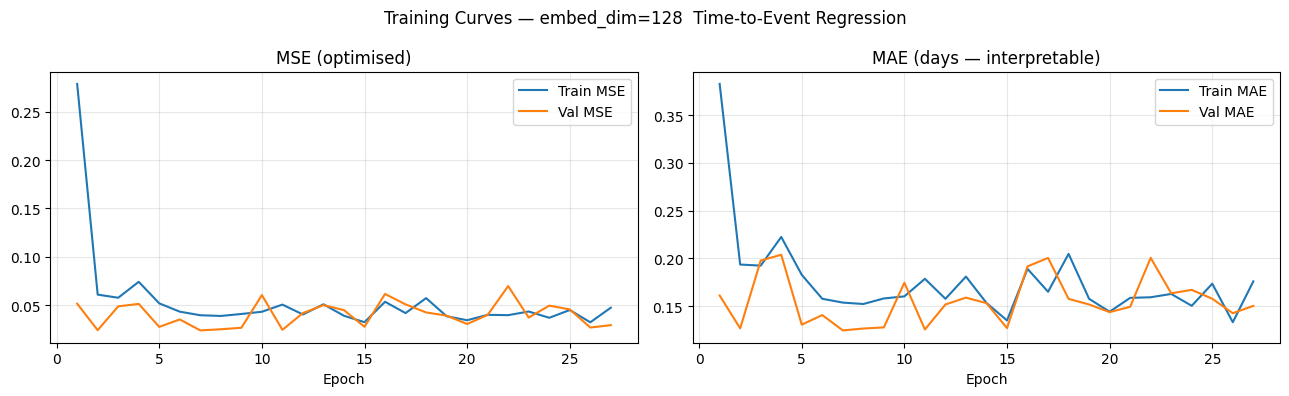


✅ Best Val MSE=0.02373
   Model saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days/128dim/best_model.pth


In [ ]:
# ── Model ────────────────────────────────────────────────────────────────────
EMBED_DIM  = 128
NHEAD      = 4
HIDDEN_DIM = 512
NUM_LAYERS = 2

dim_save        = os.path.join(SAVE_DIR, f'{EMBED_DIM}dim')
os.makedirs(dim_save, exist_ok=True)
best_model_path = os.path.join(dim_save, 'best_model.pth')
loss_plot_path  = os.path.join(dim_save, 'loss_curve.png')

model = TimeToEventTransformer(
    value_type_num=VALUE_TYPE_NUM, embed_dim=EMBED_DIM,
    nhead=NHEAD, num_layers=NUM_LAYERS,
    hidden_dim=HIDDEN_DIM, dropout=0.2, pool_size=4,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'embed_dim={EMBED_DIM}  params={n_params:,}')
print(model)

criterion_mse = nn.MSELoss()   # optimised
criterion_mae = nn.L1Loss()    # reported
optimizer     = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=1e-5)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',factor=0.5,patience=10)
grad_scaler   = GradScaler(enabled=torch.cuda.is_available())

NUM_EPOCHS          = 200
EARLY_STOP_PATIENCE = 20
best_val_mse        = float('inf')
early_stop_cnt      = 0
history = {'train_mse':[],'val_mse':[],'train_mae':[],'val_mae':[]}
shape_logged = False

for epoch in range(1, NUM_EPOCHS+1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    tr_mse, tr_mae = [], []
    for batch in tqdm(train_loader, desc=f'Train {epoch}/{NUM_EPOCHS}', leave=False):
        try:
            pm, tt, tv, tfs, hod, tgt, pids, _ = batch
            pm  = pm.to(device); tt = tt.to(device)
            tv  = torch.nan_to_num(tv.to(device),  nan=0.0)
            tfs = torch.nan_to_num(tfs.to(device), nan=0.0)
            hod = torch.nan_to_num(hod.to(device), nan=0.0)
            tgt = torch.nan_to_num(torch.as_tensor(tgt,device=device,dtype=torch.float32),nan=0.0)
            if not shape_logged:
                print(f'  Shapes: mask={tuple(pm.shape)} types={tuple(tt.shape)} target={tuple(tgt.shape)}')
                print(f'  Target range: [{float(tgt.min()):.3f}, {float(tgt.max()):.3f}]  (expect 0..1)')
                shape_logged = True
            optimizer.zero_grad(set_to_none=True)
            with autocast_ctx():
                pred = model(pm, tt, tv, tfs, hod)
                loss_mse = criterion_mse(pred, tgt)
                loss_mae = criterion_mae(pred, tgt)
            if torch.isnan(loss_mse): continue
            grad_scaler.scale(loss_mse).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            grad_scaler.step(optimizer); grad_scaler.update()
            tr_mse.append(loss_mse.item()); tr_mae.append(loss_mae.item())
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache(); continue

    # ── Val ────────────────────────────────────────────────────────────────
    model.eval()
    va_mse, va_mae = [], []
    with torch.no_grad():
        for batch in val_loader:
            try:
                pm, tt, tv, tfs, hod, tgt, pids, _ = batch
                pm  = pm.to(device); tt = tt.to(device)
                tv  = torch.nan_to_num(tv.to(device),  nan=0.0)
                tfs = torch.nan_to_num(tfs.to(device), nan=0.0)
                hod = torch.nan_to_num(hod.to(device), nan=0.0)
                tgt = torch.nan_to_num(torch.as_tensor(tgt,device=device,dtype=torch.float32),nan=0.0)
                with autocast_ctx():
                    pred = model(pm, tt, tv, tfs, hod)
                    va_mse.append(criterion_mse(pred,tgt).item())
                    va_mae.append(criterion_mae(pred,tgt).item())
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache(); continue

    t_mse = sum(tr_mse)/max(1,len(tr_mse)); t_mae = sum(tr_mae)/max(1,len(tr_mae))
    v_mse = sum(va_mse)/max(1,len(va_mse)); v_mae = sum(va_mae)/max(1,len(va_mae))
    history['train_mse'].append(t_mse); history['val_mse'].append(v_mse)
    history['train_mae'].append(t_mae); history['val_mae'].append(v_mae)
    scheduler.step(v_mse)
    lr_now = optimizer.param_groups[0]['lr']

    marker = ''
    if v_mse < best_val_mse:
        best_val_mse = v_mse
        state = model.module.state_dict() if isinstance(model,nn.DataParallel) else model.state_dict()
        torch.save(state, best_model_path)
        early_stop_cnt = 0; marker = '✅ saved'
    else:
        early_stop_cnt += 1
        if early_stop_cnt >= EARLY_STOP_PATIENCE:
            print(f'  Early stopping at epoch {epoch}'); break

    print(f'  Ep {epoch:03d}  TrainMSE={t_mse:.5f}  ValMSE={v_mse:.5f}  '
          f'TrainMAE={t_mae:.5f}  ValMAE={v_mae:.5f}  LR={lr_now:.6f}  {marker}')

# ── Loss curve ────────────────────────────────────────────────────────────────
ep = range(1, len(history['train_mse'])+1)
fig, axes = plt.subplots(1, 2, figsize=(13,4))
fig.suptitle(f'Training Curves — embed_dim={EMBED_DIM}  Time-to-Event Regression', fontsize=12)
axes[0].plot(ep, history['train_mse'], label='Train MSE')
axes[0].plot(ep, history['val_mse'],   label='Val MSE')
axes[0].set_title('MSE (optimised)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['train_mae'], label='Train MAE')
axes[1].plot(ep, history['val_mae'],   label='Val MAE')
axes[1].set_title('MAE (days — interpretable)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=150); plt.show()
print(f'\n✅ Best Val MSE={best_val_mse:.5f}')
print(f'   Model saved → {best_model_path}')
gc.collect(); torch.cuda.empty_cache()


---
## Step 8 — Evaluate & Paper Charts  (embed_dim=128)

Charts produced:
- Per-patient scatter: x=actual time to event, y=predicted (axes 6→0)
- Combined scatter (test): predicted vs actual with R² in title
- Mean per-day line plot (train/val/test), axes 6→0
- Residual distribution histogram
- Per-patient per-day CSV for all splits + combined CSV


  ✅ Loaded /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days/128dim/best_model.pth

  METRICS — embed_dim=128
   Split       MSE      RMSE       MAE        R²
  ---------------------------------------------
   train    1.2988    1.1396    0.9859    0.6831
     val    0.7279    0.8532    0.7282    0.8062
    test    1.0887    1.0434    0.9074    0.7415

  PER-PATIENT TABLE — TRAIN  (embed_dim=128)
 patient_id  day  actual_days  pred_days  error_days
         58    0          0.0       0.30        0.30
         58    1          1.0       0.62       -0.38
         58    2          2.0       1.00       -1.00
         58    3          3.0       1.60       -1.40
         58    4          4.0       2.46       -1.54
         58    5          5.0       3.42       -1.58
         58    6          6.0       4.33       -1.67
         60    0          0.0       0.46        0.46
         60    1          1.0       0.81       -0.19
         60 

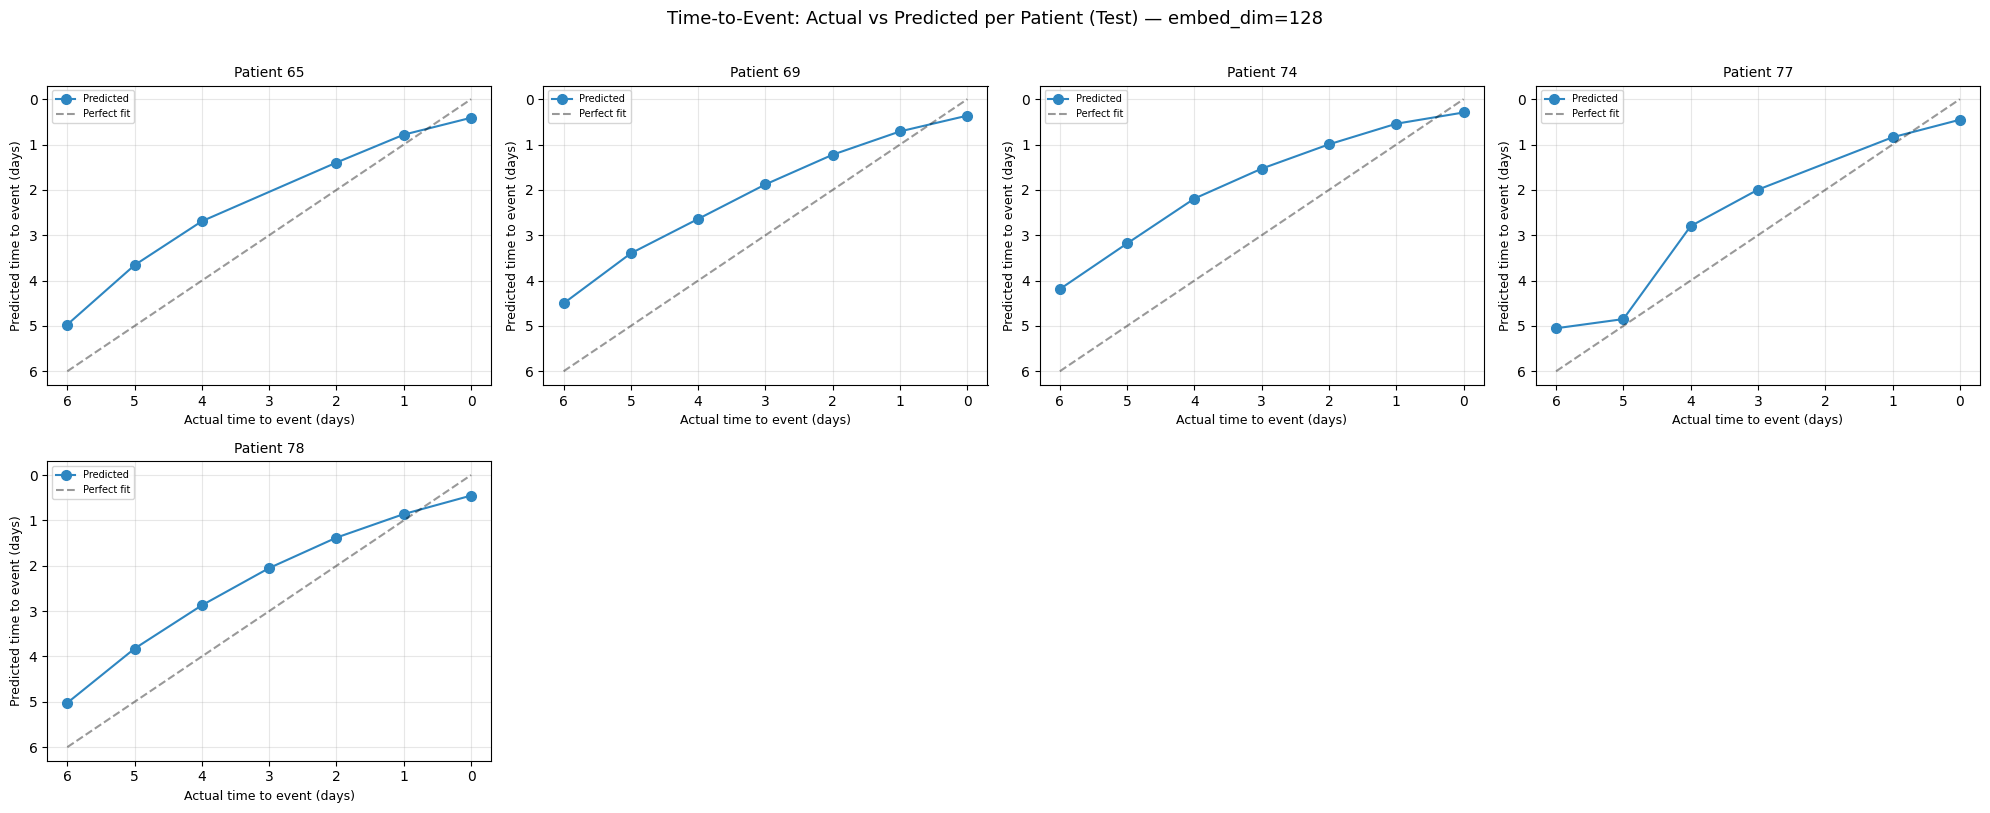

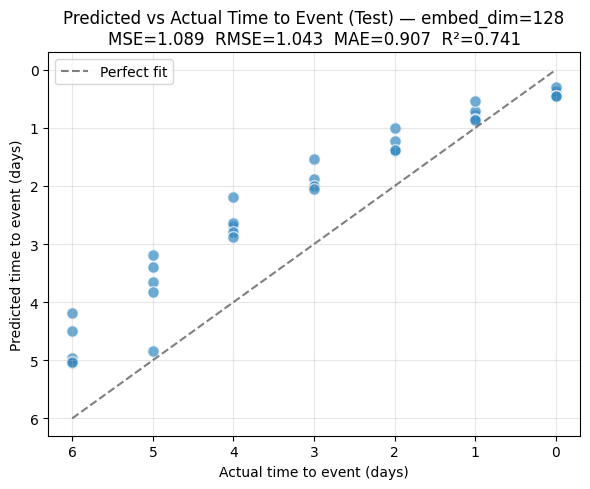

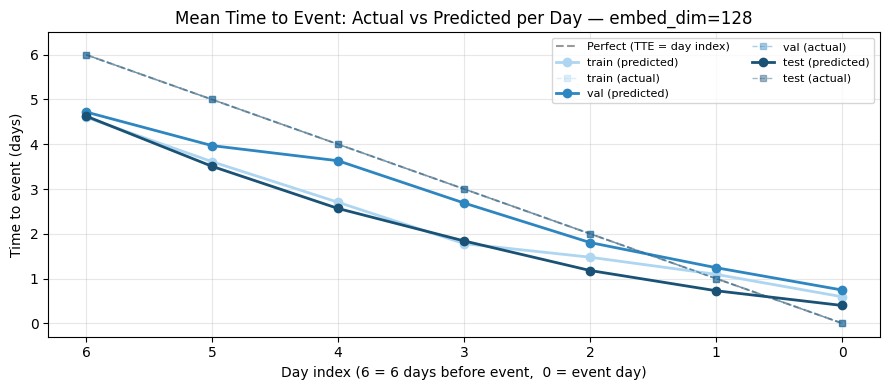

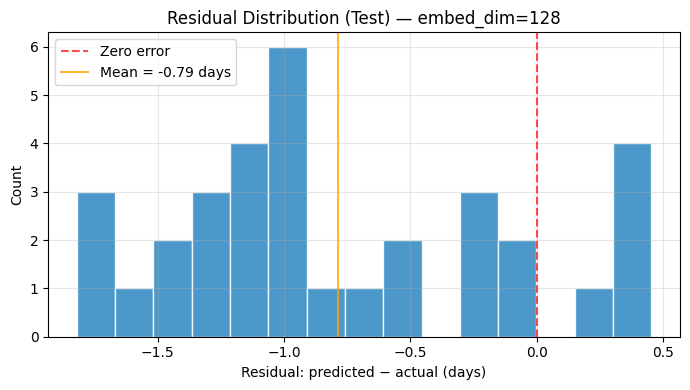


✅ All charts & tables saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days/128dim


In [ ]:
# ── Load best model ───────────────────────────────────────────────────────────
EMBED_DIM  = 128
NHEAD      = 4
HIDDEN_DIM = 512
dim_save        = os.path.join(SAVE_DIR, f'{EMBED_DIM}dim')
best_model_path = os.path.join(dim_save, 'best_model.pth')
model_eval, dev = load_best_model(best_model_path, EMBED_DIM, NHEAD, HIDDEN_DIM)

# ── Collect predictions ───────────────────────────────────────────────────────
split_dfs = {}
for sname, loader in [('train', train_loader),
                       ('val',   val_loader),
                       ('test',  test_loader)]:
    df_p = collect_predictions(loader, model_eval, log_target_scaler, dev)
    df_p['split'] = sname
    split_dfs[sname] = df_p

# ── Metrics table ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  METRICS — embed_dim={EMBED_DIM}')
print(f'{"="*60}')
print(f'  {"Split":>6}  {"MSE":>8}  {"RMSE":>8}  {"MAE":>8}  {"R²":>8}')
print('  ' + '-'*45)
metrics = {}
for sname, df_p in split_dfs.items():
    m = compute_metrics(df_p)
    metrics[sname] = m
    print(f'  {sname:>6}  {m["MSE"]:>8.4f}  {m["RMSE"]:>8.4f}  '
          f'{m["MAE"]:>8.4f}  {m["R2"]:>8.4f}')

# ── Per-patient table: train + val + test ─────────────────────────────────────
# Prints actual vs predicted time to event for every patient, every day, every split
for sname in ['train', 'val', 'test']:
    df_p  = split_dfs[sname]
    tbl   = (df_p.groupby(['patient_id', 'day'], as_index=False)
                  .agg(actual_days=('time_to_event_actual', 'mean'),
                       pred_days  =('time_to_event_pred',   'mean')))
    tbl['error_days']  = (tbl['pred_days'] - tbl['actual_days']).round(2)
    tbl['actual_days'] = tbl['actual_days'].round(2)
    tbl['pred_days']   = tbl['pred_days'].round(2)
    tbl = tbl.sort_values(['patient_id', 'day'])
    print(f'\n{"="*65}')
    print(f'  PER-PATIENT TABLE — {sname.upper()}  (embed_dim={EMBED_DIM})')
    print(f'{"="*65}')
    print(tbl.to_string(index=False))
    tbl.to_csv(os.path.join(dim_save, f'per_patient_{sname}.csv'), index=False)
    print(f'  Saved → per_patient_{sname}.csv')


# ── Combined per-patient table — ALL splits ───────────────────────────────────
all_raw = pd.concat(split_dfs.values(), ignore_index=True)
full_tbl = (all_raw.groupby(['patient_id', 'split', 'day'], as_index=False)
                   .agg(actual_days=('time_to_event_actual', 'mean'),
                        pred_days  =('time_to_event_pred',   'mean')))
full_tbl['error_days']  = (full_tbl['pred_days'] - full_tbl['actual_days']).round(3)
full_tbl['actual_days'] = full_tbl['actual_days'].round(3)
full_tbl['pred_days']   = full_tbl['pred_days'].round(3)
split_order = {'train': 0, 'val': 1, 'test': 2}
full_tbl['_ord'] = full_tbl['split'].map(split_order)
full_tbl = (full_tbl.sort_values(['_ord', 'patient_id', 'day'])
                    .drop(columns='_ord')
                    .reset_index(drop=True))

print(f'\n{"="*70}')
print(f'  FULL PER-PATIENT TABLE — ALL SPLITS  (embed_dim={EMBED_DIM})')
print(f'  {full_tbl["patient_id"].nunique()} patients total  |  '
      f'train={split_dfs["train"]["patient_id"].nunique()}  '
      f'val={split_dfs["val"]["patient_id"].nunique()}  '
      f'test={split_dfs["test"]["patient_id"].nunique()}')
print(f'  Columns: patient_id | split | day (0=event day, 6=6 days before) | '
      f'actual_days | pred_days | error_days')
print(f'{"="*70}')
print(full_tbl.to_string(index=False))

csv_path = os.path.join(dim_save, 'per_patient_all_splits.csv')
full_tbl.to_csv(csv_path, index=False)
print(f'\n  → Saved: per_patient_all_splits.csv  '
      f'({len(full_tbl)} rows, {full_tbl["patient_id"].nunique()} patients)')

# ── Chart 1: Per-patient scatter — x=actual TTE, y=predicted TTE ─────────────
# x-axis and y-axis both go from 6 → 0 (time to event decreases toward event)
# One subplot per patient, TEST split
test_df   = split_dfs['test']
test_pids = sorted(test_df['patient_id'].unique())
n_pats    = len(test_pids)
n_cols    = min(4, n_pats)
n_rows    = (n_pats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5*n_cols, 4*n_rows), squeeze=False)
fig.suptitle(f'Time-to-Event: Actual vs Predicted per Patient (Test) — embed_dim={EMBED_DIM}',
             fontsize=13, y=1.01)

for idx, pid in enumerate(test_pids):
    ax  = axes[idx//n_cols][idx%n_cols]
    sub = (test_df[test_df['patient_id'] == pid]
           .groupby('day', as_index=False)
           .agg(actual=('time_to_event_actual', 'mean'),
                pred  =('time_to_event_pred',   'mean'))
           .sort_values('day'))

    ax.plot(sub['actual'], sub['pred'], 'o-', color='#2E86C1',
            markersize=7, linewidth=1.5, label='Predicted')
    # perfect fit line: x=y from 6 down to 0
    ax.plot([6, 0], [6, 0], 'k--', alpha=0.4, label='Perfect fit')
    # axes both run 6 → 0
    ax.set_xlim(6.3, -0.3)
    ax.set_ylim(6.3, -0.3)
    ax.set_xlabel('Actual time to event (days)', fontsize=9)
    ax.set_ylabel('Predicted time to event (days)', fontsize=9)
    ax.set_title(f'Patient {pid}', fontsize=10)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

for idx in range(n_pats, n_rows * n_cols):
    axes[idx//n_cols][idx%n_cols].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'per_patient_tte_scatter.png'), dpi=150)
plt.show()

# ── Chart 2: All patients combined scatter (test) — axes 6→0 ────────────────
test_daily = metrics['test']['daily']
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test_daily['actual'], test_daily['pred'],
           c='#2E86C1', alpha=0.7, edgecolors='white', s=70)
# perfect fit line 6→0
ax.plot([6, 0], [6, 0], 'k--', alpha=0.5, label='Perfect fit')
ax.set_xlim(6.3, -0.3)
ax.set_ylim(6.3, -0.3)
ax.set_xlabel('Actual time to event (days)')
ax.set_ylabel('Predicted time to event (days)')
ax.set_title(f'Predicted vs Actual Time to Event (Test) — embed_dim={EMBED_DIM}\n'
             f'MSE={metrics["test"]["MSE"]:.3f}  RMSE={metrics["test"]["RMSE"]:.3f}  '
             f'MAE={metrics["test"]["MAE"]:.3f}  R²={metrics["test"]["R2"]:.3f}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'scatter_test.png'), dpi=150)
plt.show()

# ── Chart 3: Mean predicted vs actual per day (all splits) ───────────────────
# x-axis = day index (6→0), y-axis = time to event (6→0)
# Perfect line: at day 6, TTE should be 6; at day 0, TTE should be 0
all_preds = pd.concat(split_dfs.values(), ignore_index=True)
daily_agg = (all_preds.groupby(['split', 'day'], as_index=False)
                       .agg(actual_mean=('time_to_event_actual', 'mean'),
                            pred_mean  =('time_to_event_pred',   'mean')))

fig, ax = plt.subplots(figsize=(9, 4))
# Perfect line: day index = time to event (day 6 → TTE=6, day 0 → TTE=0)
ax.plot([6, 5, 4, 3, 2, 1, 0],
        [6, 5, 4, 3, 2, 1, 0],
        'k--', alpha=0.4, label='Perfect (TTE = day index)')

colors = {'train': '#AED6F1', 'val': '#2E86C1', 'test': '#1A5276'}
for sname in ['train', 'val', 'test']:
    sub = daily_agg[daily_agg['split'] == sname].sort_values('day', ascending=False)
    ax.plot(sub['day'], sub['pred_mean'], 'o-',
            color=colors[sname], label=f'{sname} (predicted)',
            linewidth=2, markersize=6)
    ax.plot(sub['day'], sub['actual_mean'], 's--',
            color=colors[sname], alpha=0.4, label=f'{sname} (actual)',
            linewidth=1, markersize=5)

ax.set_xlim(6.3, -0.3)        # x goes 6 → 0
ax.set_ylim(-0.3, 6.5)        # y goes 0 → 6
ax.set_xlabel('Day index (6 = 6 days before event,  0 = event day)')
ax.set_ylabel('Time to event (days)')
ax.set_title(f'Mean Time to Event: Actual vs Predicted per Day — embed_dim={EMBED_DIM}')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'per_day_tte_line.png'), dpi=150)
plt.show()

# ── Chart 4: Residual distribution (test) ────────────────────────────────────
resid = test_daily['pred'].values - test_daily['actual'].values
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(resid, bins=15, color='#2E86C1', edgecolor='white', alpha=0.85)
ax.axvline(0,            color='red',    linestyle='--', alpha=0.7, label='Zero error')
ax.axvline(resid.mean(), color='orange', linestyle='-',  alpha=0.8,
           label=f'Mean = {resid.mean():.2f} days')
ax.set_xlabel('Residual: predicted − actual (days)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (Test) — embed_dim={EMBED_DIM}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'residuals_test.png'), dpi=150)
plt.show()

print(f'\n✅ All charts & tables saved → {dim_save}')
del model_eval; gc.collect(); torch.cuda.empty_cache()


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import drive
drive.mount('/content/drive')
# ── Load the per-patient CSVs saved by Step 8 ────────────────────────────────
EMBED_DIM = 128
dim_save  = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Regression/regression_last7days/128dim"

df_train = pd.read_csv(f'{dim_save}/per_patient_train.csv')
df_val   = pd.read_csv(f'{dim_save}/per_patient_val.csv')
df_test  = pd.read_csv(f'{dim_save}/per_patient_test.csv')

# Label each split
df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'Total patients: {df_all["patient_id"].nunique()}')
print(f'Total patient-day points: {len(df_all)}')

# ── Compute per-patient metrics (each patient = one LOOCV fold result) ────────
loocv_rows = []
for pid in sorted(df_all['patient_id'].unique()):
    sub = df_all[df_all['patient_id'] == pid]
    yt  = sub['actual_days'].values
    yp  = sub['pred_days'].values
    n   = len(sub)
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = float(r2_score(yt, yp)) if (n >= 2 and np.var(yt) > 0) else float('nan')
    split = sub['split'].iloc[0]
    loocv_rows.append({
        'patient_id': pid,
        'split':      split,
        'n_days':     n,
        'rmse':       round(rmse, 4),
        'mae':        round(mae,  4),
        'r2':         round(r2,   4),
    })
    print(f'  Patient {pid:>4} ({split:>5})  n_days={n}  '
          f'MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')

loocv_df = pd.DataFrame(loocv_rows)

# ── Summary ───────────────────────────────────────────────────────────────────
rmse_vals = loocv_df['rmse'].values
mae_vals  = loocv_df['mae'].values
r2_vals   = loocv_df['r2'].dropna().values

print(f'\n{"="*60}')
print(f'LOOCV-style Summary — embed_dim={EMBED_DIM} (all 29 patients)')
print(f'{"="*60}')
print(f'  RMSE : mean={rmse_vals.mean():.4f}  std={rmse_vals.std():.4f}  '
      f'[{rmse_vals.min():.4f} – {rmse_vals.max():.4f}]')
print(f'  MAE  : mean={mae_vals.mean():.4f}  std={mae_vals.std():.4f}  '
      f'[{mae_vals.min():.4f} – {mae_vals.max():.4f}]')
print(f'  R²   : mean={r2_vals.mean():.4f}  std={r2_vals.std():.4f}  '
      f'[{r2_vals.min():.4f} – {r2_vals.max():.4f}]')

# ── Also report by split ──────────────────────────────────────────────────────
print(f'\n  By split:')
for split in ['train', 'val', 'test']:
    sub = loocv_df[loocv_df['split'] == split]
    print(f'    {split:>5}: n={len(sub)}  '
          f'RMSE={sub["rmse"].mean():.3f}±{sub["rmse"].std():.3f}  '
          f'MAE={sub["mae"].mean():.3f}±{sub["mae"].std():.3f}  '
          f'R²={sub["r2"].mean():.3f}±{sub["r2"].std():.3f}')

loocv_df.to_csv(f'{dim_save}/loocv_from_step8_{EMBED_DIM}dim.csv', index=False)
print(f'\n✅ Saved: loocv_from_step8_{EMBED_DIM}dim.csv')

Mounted at /content/drive
Total patients: 29
Total patient-day points: 186
  Patient   58 (train)  n_days=7  MAE=1.124  RMSE=1.245  R²=0.612
  Patient   59 (  val)  n_days=7  MAE=1.054  RMSE=1.160  R²=0.663
  Patient   60 (train)  n_days=7  MAE=0.823  RMSE=0.899  R²=0.798
  Patient   61 (train)  n_days=7  MAE=0.881  RMSE=0.966  R²=0.767
  Patient   62 (train)  n_days=7  MAE=1.027  RMSE=1.141  R²=0.674
  Patient   63 (train)  n_days=6  MAE=1.297  RMSE=1.436  R²=0.469
  Patient   64 (train)  n_days=7  MAE=0.913  RMSE=1.006  R²=0.747
  Patient   65 ( test)  n_days=6  MAE=0.818  RMSE=0.926  R²=0.816
  Patient   66 (train)  n_days=6  MAE=1.080  RMSE=1.148  R²=0.661
  Patient   67 (train)  n_days=7  MAE=0.950  RMSE=1.048  R²=0.726
  Patient   68 (train)  n_days=3  MAE=2.730  RMSE=2.730  R²=-10.183
  Patient   69 ( test)  n_days=7  MAE=1.001  RMSE=1.117  R²=0.688
  Patient   70 (train)  n_days=6  MAE=0.995  RMSE=1.045  R²=0.719
  Patient   71 (train)  n_days=7  MAE=1.064  RMSE=1.176  R²=0.654

In [2]:
# ── Summary excluding Patient 68 (only 3 days, unstable R²) ──────────────────
loocv_clean = loocv_df[loocv_df['patient_id'] != 68]

rmse_vals = loocv_clean['rmse'].values
mae_vals  = loocv_clean['mae'].values
r2_vals   = loocv_clean['r2'].dropna().values

print(f'{"="*60}')
print(f'Summary — all 29 patients')
print(f'{"="*60}')
print(f'  RMSE : mean={loocv_df["rmse"].mean():.4f}  std={loocv_df["rmse"].std():.4f}')
print(f'  MAE  : mean={loocv_df["mae"].mean():.4f}  std={loocv_df["mae"].std():.4f}')
print(f'  R²   : mean={loocv_df["r2"].mean():.4f}  std={loocv_df["r2"].std():.4f}')

print(f'\n{"="*60}')
print(f'Summary — 28 patients (excluding P68, n_days=3)')
print(f'{"="*60}')
print(f'  RMSE : mean={rmse_vals.mean():.4f}  std={rmse_vals.std():.4f}  '
      f'[{rmse_vals.min():.4f} – {rmse_vals.max():.4f}]')
print(f'  MAE  : mean={mae_vals.mean():.4f}  std={mae_vals.std():.4f}  '
      f'[{mae_vals.min():.4f} – {mae_vals.max():.4f}]')
print(f'  R²   : mean={r2_vals.mean():.4f}  std={r2_vals.std():.4f}  '
      f'[{r2_vals.min():.4f} – {r2_vals.max():.4f}]')

print(f'\n  By split (28 patients):')
for split in ['train', 'val', 'test']:
    sub = loocv_clean[loocv_clean['split'] == split]
    print(f'    {split:>5}: n={len(sub)}  '
          f'RMSE={sub["rmse"].mean():.3f}±{sub["rmse"].std():.3f}  '
          f'MAE={sub["mae"].mean():.3f}±{sub["mae"].std():.3f}  '
          f'R²={sub["r2"].mean():.3f}±{sub["r2"].std():.3f}')

# Save both
loocv_df.to_csv(f'{dim_save}/loocv_all29_{EMBED_DIM}dim.csv', index=False)
loocv_clean.to_csv(f'{dim_save}/loocv_28patients_{EMBED_DIM}dim.csv', index=False)
print(f'\n✅ Both CSVs saved.')

Summary — all 29 patients
  RMSE : mean=1.0481  std=0.4098
  MAE  : mean=0.9488  std=0.4167
  R²   : mean=0.3650  std=2.0323

Summary — 28 patients (excluding P68, n_days=3)
  RMSE : mean=0.9880  std=0.2514  [0.3935 – 1.4364]
  MAE  : mean=0.8852  std=0.2372  [0.3020 – 1.2967]
  R²   : mean=0.7418  std=0.1208  [0.4694 – 0.9550]

  By split (28 patients):
    train: n=18  RMSE=1.036±0.241  MAE=0.932±0.226  R²=0.720±0.120
      val: n=5  RMSE=0.793±0.279  MAE=0.704±0.272  R²=0.818±0.110
     test: n=5  RMSE=1.010±0.242  MAE=0.897±0.228  R²=0.742±0.139

✅ Both CSVs saved.


##Step 10 Baseline

In [1]:
## Step 10 — Simple Baselines for Stage 2 TTE Regression (reviewer 2.1)
#
# CHANGE THIS ONE LINE to switch between dims:
EMBED_DIM = 128   # ← change to 64 or 128
#
# Baselines (all use hand-crafted features, no transformer):
#   1. Naive mean   — predict mean TTE of training set for everyone
#   2. Naive median — predict median TTE of training set for everyone
#   3. Ridge regression on hand-crafted per-day pressure/flow features
#   4. XGBoost regression on same features
#
# Transformer results loaded automatically from Step 8 CSVs.
# Bootstrap CI for transformer computed inline (no Step 9 needed).
#
# Features per patient-day (8 features):
#   mean/std/min/max of pressure + mean/std/min/max of flow
#
# Standalone — mount Drive and run. Step 8 must have run first.

import os
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from google.colab import drive
drive.mount('/content/drive')

RANDOM_SEED = 42
N_BOOTSTRAP = 2000
rng = np.random.default_rng(RANDOM_SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
LABEL1_DIR = ("/content/drive/My Drive/Monmouth_University/2025_RA"
              "/Medical_AI/Cleaned_Data/last7days_rawdata_label1only_parquet")
REG_DIR    = ("/content/drive/My Drive/Monmouth_University/2025_RA"
              f"/Medical_AI/Regression/regression_last7days/{EMBED_DIM}dim")

print(f'Config: EMBED_DIM={EMBED_DIM}')

# ── Load raw parquets ─────────────────────────────────────────────────────────
print('\nLoading raw label-1 parquets...')
df_train = pd.read_parquet(f'{LABEL1_DIR}/train.parquet')
df_val   = pd.read_parquet(f'{LABEL1_DIR}/val.parquet')
df_test  = pd.read_parquet(f'{LABEL1_DIR}/test.parquet')

print(f'  Train: {df_train["patient_id"].nunique()} patients  {len(df_train):,} rows')
print(f'  Val  : {df_val["patient_id"].nunique()} patients  {len(df_val):,} rows')
print(f'  Test : {df_test["patient_id"].nunique()} patients  {len(df_test):,} rows')

# ── Build per-(patient, day) features ────────────────────────────────────────
def build_features(df):
    """
    One row per (patient, countdown_days_target).
    Features: mean/std/min/max of pressure and flow for that day.
    Target: countdown_days_target (0–6 days until event).
    """
    pressure = df[df['test_type'] == 'pressure']
    flow     = df[df['test_type'] == 'flow']

    p_stats = (pressure.groupby(['patient_id', 'countdown_days_target'])
                       ['test_value']
                       .agg(mean_pressure='mean', std_pressure='std',
                            min_pressure='min',   max_pressure='max')
                       .reset_index())
    f_stats = (flow.groupby(['patient_id', 'countdown_days_target'])
                   ['test_value']
                   .agg(mean_flow='mean', std_flow='std',
                        min_flow='min',   max_flow='max')
                   .reset_index())

    merged = pd.merge(p_stats, f_stats,
                      on=['patient_id', 'countdown_days_target'],
                      how='outer').fillna(0)
    merged = merged.rename(columns={'countdown_days_target': 'day'})
    return merged

print('\nBuilding per-patient-day features...')
feat_train    = build_features(df_train)
feat_val      = build_features(df_val)
feat_test     = build_features(df_test)
feat_trainval = pd.concat([feat_train, feat_val], ignore_index=True)

FEAT_COLS  = ['mean_pressure', 'std_pressure', 'min_pressure', 'max_pressure',
              'mean_flow',     'std_flow',     'min_flow',     'max_flow']
TARGET_COL = 'day'

X_train = feat_trainval[FEAT_COLS].values
y_train = feat_trainval[TARGET_COL].values
X_test  = feat_test[FEAT_COLS].values
y_test  = feat_test[TARGET_COL].values

print(f'  Train+val: {len(X_train)} patient-day rows  '
      f'y range=[{y_train.min():.1f}–{y_train.max():.1f}]  '
      f'mean={y_train.mean():.3f}')
print(f'  Test     : {len(X_test)} patient-day rows  '
      f'y range=[{y_test.min():.1f}–{y_test.max():.1f}]  '
      f'mean={y_test.mean():.3f}')
print(f'  Features : {FEAT_COLS}')

# Scale features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Helpers ───────────────────────────────────────────────────────────────────
def point_metrics(yt, yp, label):
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = float(r2_score(yt, yp)) if np.var(yt) > 0 else float('nan')
    print(f'  [{label}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return rmse, mae, r2

def bootstrap_ci(yt, yp, label, n_boot=N_BOOTSTRAP):
    n = len(yt)
    bs_rmse, bs_mae, bs_r2 = [], [], []
    for _ in range(n_boot):
        idx    = rng.integers(0, n, size=n)
        yb, pb = yt[idx], yp[idx]
        if np.var(yb) == 0: continue
        bs_rmse.append(float(np.sqrt(mean_squared_error(yb, pb))))
        bs_mae.append(float(mean_absolute_error(yb, pb)))
        bs_r2.append(float(r2_score(yb, pb)))
    pt_rmse  = float(np.sqrt(mean_squared_error(yt, yp)))
    pt_mae   = float(mean_absolute_error(yt, yp))
    pt_r2    = float(r2_score(yt, yp)) if np.var(yt) > 0 else float('nan')
    rl,  rh  = np.percentile(bs_rmse, [2.5, 97.5])
    ml,  mh  = np.percentile(bs_mae,  [2.5, 97.5])
    r2l, r2h = np.percentile(bs_r2,   [2.5, 97.5])
    print(f'\n  [{label}] Bootstrap 95% CI ({len(bs_rmse)} resamples):')
    print(f'    RMSE: {pt_rmse:.4f}  [{rl:.4f} – {rh:.4f}]')
    print(f'    MAE : {pt_mae:.4f}  [{ml:.4f}  – {mh:.4f}]')
    print(f'    R²  : {pt_r2:.4f}  [{r2l:.4f}   – {r2h:.4f}]')
    return {'model':    label,
            'embed_dim': EMBED_DIM,
            'n_points':  n,
            'rmse':     round(pt_rmse, 4), 'rmse_lo': round(rl,   4), 'rmse_hi': round(rh,   4),
            'mae':      round(pt_mae,  4), 'mae_lo':  round(ml,   4), 'mae_hi':  round(mh,   4),
            'r2':       round(pt_r2,   4), 'r2_lo':   round(r2l,  4), 'r2_hi':   round(r2h,  4)}

# ═════════════════════════════════════════════════════════════════════════════
# BASELINE 1 — Naive Mean & Median
# ═════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('BASELINE 1: Naive Mean / Median')
print('='*60)
mean_tte   = float(y_train.mean())
median_tte = float(np.median(y_train))
print(f'  Training mean TTE   = {mean_tte:.4f} days')
print(f'  Training median TTE = {median_tte:.4f} days')

ci_mean   = bootstrap_ci(y_test, np.full(len(y_test), mean_tte),   'Naive Mean')
ci_median = bootstrap_ci(y_test, np.full(len(y_test), median_tte), 'Naive Median')

# ═════════════════════════════════════════════════════════════════════════════
# BASELINE 2 — Ridge Regression
# ═════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('BASELINE 2: Ridge Regression (hand-crafted pressure/flow features)')
print('='*60)

ridge = Ridge(alpha=1.0, random_state=RANDOM_SEED)
ridge.fit(X_train_sc, y_train)
point_metrics(y_train, ridge.predict(X_train_sc), 'Ridge — train+val')
ci_ridge = bootstrap_ci(y_test, ridge.predict(X_test_sc), 'Ridge')

# ═════════════════════════════════════════════════════════════════════════════
# BASELINE 3 — XGBoost Regression
# ═════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('BASELINE 3: XGBoost Regression (hand-crafted pressure/flow features)')
print('='*60)

xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                   random_state=RANDOM_SEED, verbosity=0)
xgb.fit(X_train_sc, y_train)
point_metrics(y_train, xgb.predict(X_train_sc), 'XGBoost — train+val')
ci_xgb = bootstrap_ci(y_test, xgb.predict(X_test_sc), 'XGBoost')

# ═════════════════════════════════════════════════════════════════════════════
# TRANSFORMER — load from Step 8 CSVs + compute CI inline
# ═════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('TRANSFORMER — loading Step 8 predictions + computing bootstrap CI')
print('='*60)

tgt_csv = pd.read_csv(f'{REG_DIR}/per_patient_test.csv')

# Aggregate to patient-day level (same granularity as baselines)
test_daily = (tgt_csv.groupby(['patient_id', 'day'], as_index=False)
                     .agg(actual=('actual_days', 'mean'),
                          pred  =('pred_days',   'mean')))
yt_tr = test_daily['actual'].values
yp_tr = test_daily['pred'].values

print(f'  Loaded: {len(test_daily)} patient-day points  '
      f'({test_daily["patient_id"].nunique()} patients)')
point_metrics(yt_tr, yp_tr, 'Transformer — test point estimates')

ci_transformer = bootstrap_ci(yt_tr, yp_tr, 'Transformer (ours)')
ci_transformer['embed_dim'] = EMBED_DIM

# Save transformer CI for reference
ci_save_df = pd.DataFrame([{
    'embed_dim':   EMBED_DIM,
    'n_points':    len(test_daily),
    'rmse_point':  ci_transformer['rmse'],
    'rmse_lower':  ci_transformer['rmse_lo'],
    'rmse_upper':  ci_transformer['rmse_hi'],
    'mae_point':   ci_transformer['mae'],
    'mae_lower':   ci_transformer['mae_lo'],
    'mae_upper':   ci_transformer['mae_hi'],
    'r2_point':    ci_transformer['r2'],
    'r2_lower':    ci_transformer['r2_lo'],
    'r2_upper':    ci_transformer['r2_hi'],
}])
ci_save_path = os.path.join(REG_DIR, f'bootstrap_ci_regression_{EMBED_DIM}dim.csv')
ci_save_df.to_csv(ci_save_path, index=False)
print(f'  Saved CI: {ci_save_path}')

# ═════════════════════════════════════════════════════════════════════════════
# PAPER-READY COMPARISON TABLE
# ═════════════════════════════════════════════════════════════════════════════
print(f'\n{"="*85}')
print(f'PAPER-READY COMPARISON TABLE — embed_dim={EMBED_DIM}')
print(f'Test set: {feat_test["patient_id"].nunique()} patients  '
      f'({len(y_test)} patient-day points)')
print(f'Baselines: mean/std/min/max of pressure and flow per day (no transformer)')
print(f'{"="*85}')
print(f'{"Model":<22}  {"RMSE [95% CI]":<30}  {"MAE [95% CI]":<30}  R² [95% CI]')
print('-'*105)

all_results = [ci_mean, ci_median, ci_ridge, ci_xgb, ci_transformer]
for r in all_results:
    rmse_s = f'{r["rmse"]:.3f} [{r["rmse_lo"]:.3f}–{r["rmse_hi"]:.3f}]'
    mae_s  = f'{r["mae"]:.3f} [{r["mae_lo"]:.3f}–{r["mae_hi"]:.3f}]'
    r2_s   = f'{r["r2"]:.3f} [{r["r2_lo"]:.3f}–{r["r2_hi"]:.3f}]'
    marker = ' ✅' if 'Transformer' in r['model'] else ''
    print(f'{r["model"]:<22}  {rmse_s:<30}  {mae_s:<30}  {r2_s}{marker}')

# ── Save full comparison CSV ──────────────────────────────────────────────────
comp_df  = pd.DataFrame(all_results)
comp_csv = os.path.join(REG_DIR, f'baseline_comparison_{EMBED_DIM}dim.csv')
comp_df.to_csv(comp_csv, index=False)
print(f'\n✅ Saved comparison: {comp_csv}')

Mounted at /content/drive
Config: EMBED_DIM=128

Loading raw label-1 parquets...
  Train: 19 patients  32,455,977 rows
  Val  : 5 patients  8,778,214 rows
  Test : 5 patients  5,877,474 rows

Building per-patient-day features...
  Train+val: 153 patient-day rows  y range=[0.0–6.0]  mean=2.941
  Test     : 33 patient-day rows  y range=[0.0–6.0]  mean=3.030
  Features : ['mean_pressure', 'std_pressure', 'min_pressure', 'max_pressure', 'mean_flow', 'std_flow', 'min_flow', 'max_flow']

BASELINE 1: Naive Mean / Median
  Training mean TTE   = 2.9412 days
  Training median TTE = 3.0000 days

  [Naive Mean] Bootstrap 95% CI (2000 resamples):
    RMSE: 2.0541  [1.7458 – 2.3351]
    MAE : 1.7968  [1.4474  – 2.1337]
    R²  : -0.0019  [-0.1619   – -0.0000]

  [Naive Median] Bootstrap 95% CI (2000 resamples):
    RMSE: 2.0523  [1.7408 – 2.3290]
    MAE : 1.7879  [1.4242  – 2.1515]
    R²  : -0.0002  [-0.1639   – 0.0000]

BASELINE 2: Ridge Regression (hand-crafted pressure/flow features)
  [Ridge —